In [5]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pylake

/home/leroquan@eawag.wroot.emp-eaw.ch/miniconda3/envs/horizontal_structures/lib/python3.11/site-packages/pylake/pylake.py:3: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [ ]:
lake = 'zug'
folder_path = rf"/storage/alplakes_test/{lake}_100m_2025"
input_folder = os.path.join(folder_path, "outputs_swirl", "eddy_catalogues_final")

In [3]:
df_lake = pd.read_csv(os.path.join(input_folder, "lake_characteristics.csv"))
df_lake = df_lake.set_index('id', drop=False)
df_lake['date'] = pd.to_datetime(df_lake['date'])

In [4]:
xr_lake_temp = df_lake[(
        (df_lake['depth_index'] <= 35) &
        (df_lake['depth_index'] >= 0) &
        (df_lake['date'] >= '2025-03-01') &
        (df_lake['date'] <= '2026-03-01')
    )].groupby(['date','depth_[m]'])['mean_temperature_lake_[°C]'].mean().to_xarray()
xr_lake_temp = xr_lake_temp.rename({'depth_[m]': 'Z'})

In [6]:
thermocline_depth, thermocline_idx = pylake.thermocline(xr_lake_temp.values, -1*xr_lake_temp.Z.values)

In [7]:
xr_rho = pylake.dens0(xr_lake_temp)

In [8]:
# Align dimension names and dates
thermocline = thermocline_depth.rename({"time": "date"})
thermocline = thermocline.assign_coords(date=xr_rho.date)

rho1 = xr_rho.where(
    xr_rho.Z >= -thermocline
).mean(dim="Z")

rho2 = xr_rho.where(
    xr_rho.Z < -thermocline
).mean(dim="Z")

In [9]:
gprime = 9.81*(rho2-rho1)/rho2

In [10]:
omega = 7.2921e-5  # Earth's angular velocity (rad/s)
lat_rad = np.deg2rad(46.45)# Latitude of Lake Geneva (degrees)
f = 2 * omega * np.sin(lat_rad) # Coriolis parameter

In [11]:
rossby_radius = np.sqrt(gprime*thermocline)/f

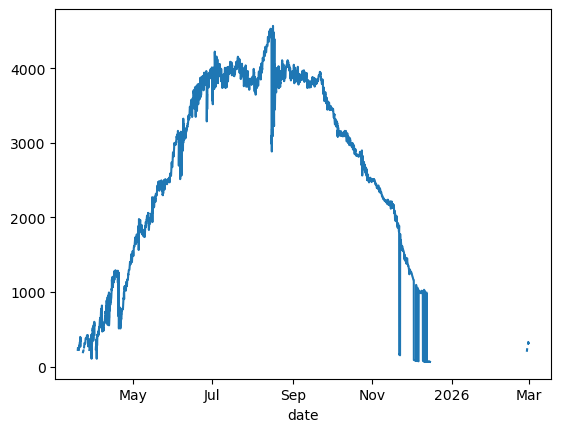

In [12]:
rossby_radius.plot()

In [15]:
f*700

np.float64(0.07399168074546983)